# E-Commerce Sales Analysis

This notebook presents an exploratory data analysis (EDA) of e-commerce transaction data.
The analysis covers key business metrics including revenue performance, product category
rankings, geographic distribution of sales, and the relationship between delivery speed
and customer satisfaction.

The analysis period is fully configurable: set `ANALYSIS_YEAR`, `ANALYSIS_MONTH`, and
`COMPARISON_YEAR` in the Configuration cell to run the analysis for any date range.

---

## Business Objectives

- Measure and track revenue performance relative to a comparison period
- Identify top-performing product categories by revenue
- Understand the geographic distribution of sales across states
- Assess the relationship between delivery speed and customer review scores

---

## Table of Contents

1. [Data Loading and Configuration](#1-data-loading--configuration)
2. [Data Preparation and Transformation](#2-data-preparation--transformation)
3. [Business Metrics Calculation](#3-business-metrics-calculation)
   - 3.1 [Revenue Analysis](#31-revenue-analysis)
   - 3.2 [Product Analysis](#32-product-analysis)
   - 3.3 [Geographic Analysis](#33-geographic-analysis)
   - 3.4 [Customer Experience Analysis](#34-customer-experience-analysis)
4. [Summary of Observations](#4-summary-of-observations)

---

## Data Dictionary

| Column | Dataset | Description |
|--------|---------|-------------|
| `order_id` | orders, order_items, reviews | Unique identifier for each order |
| `customer_id` | orders, customers | Unique customer identifier |
| `order_status` | orders | Fulfillment status of the order (e.g., delivered, canceled) |
| `order_purchase_timestamp` | orders | Date and time when the order was placed |
| `order_delivered_customer_date` | orders | Actual date the order was delivered to the customer |
| `price` | order_items | Price of a single line item in the order (in BRL) |
| `product_id` | order_items, products | Unique product identifier |
| `product_category_name` | products | Product category name |
| `customer_state` | customers | Two-letter state code for the customer's location |
| `review_score` | order_reviews | Customer rating from 1 (lowest) to 5 (highest) |

**Business Terms**

- **Revenue**: Sum of all item prices for delivered orders in the selected period
- **AOV (Average Order Value)**: Mean total revenue per order
- **YoY Growth**: Percentage change between the analysis period and the comparison period
- **MoM Growth**: Month-over-month percentage change within the analysis period
- **Delivery Speed**: Number of days from the purchase date to the delivery date

---
## 1. Data Loading & Configuration

Import libraries, load helper modules, and define analysis parameters.
Edit the configuration block below to change the analysis period.

In [1]:
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import plotly.express as px

sys.path.insert(0, '.')
from data_loader import build_sales_data, filter_by_period, get_period_label, load_datasets
from business_metrics import (
    calculate_aov,
    calculate_aov_growth,
    calculate_avg_monthly_growth,
    calculate_delivery_metrics,
    calculate_monthly_growth,
    calculate_monthly_revenue,
    calculate_order_count,
    calculate_order_count_growth,
    calculate_revenue_by_category,
    calculate_revenue_by_state,
    calculate_revenue_growth,
    calculate_review_metrics,
    calculate_total_revenue,
)

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

In [2]:
# ---------------------------------------------------------------------------
# Analysis Configuration
# ---------------------------------------------------------------------------
# DATA_DIR      : path to the folder containing the CSV datasets
# ANALYSIS_YEAR : the primary year to analyse
# ANALYSIS_MONTH: set to a month number (1-12) to restrict the analysis to
#                 a single month, or None to analyse the full year
# COMPARISON_YEAR: the baseline year used for year-over-year comparisons
# ---------------------------------------------------------------------------

DATA_DIR        = 'ecommerce_data'
ANALYSIS_YEAR   = 2023
ANALYSIS_MONTH  = None   # None = full year | 1-12 = specific month
COMPARISON_YEAR = 2022

# Derived labels (generated automatically from the settings above)
period_label     = get_period_label(ANALYSIS_YEAR, ANALYSIS_MONTH)
comparison_label = get_period_label(COMPARISON_YEAR, ANALYSIS_MONTH)

print(f'Analysis period  : {period_label}')
print(f'Comparison period: {comparison_label}')

Analysis period  : 2023
Comparison period: 2022


In [3]:
# Load all five CSV datasets
data       = load_datasets(DATA_DIR)
orders     = data['orders']
order_items = data['order_items']
products   = data['products']
customers  = data['customers']
reviews    = data['reviews']

print('Datasets loaded successfully.')
print(f'  Orders      : {len(orders):>8,} rows')
print(f'  Order items : {len(order_items):>8,} rows')
print(f'  Products    : {len(products):>8,} rows')
print(f'  Customers   : {len(customers):>8,} rows')
print(f'  Reviews     : {len(reviews):>8,} rows')

Datasets loaded successfully.
  Orders      :   10,000 rows
  Order items :   16,047 rows
  Products    :    6,000 rows
  Customers   :    8,000 rows
  Reviews     :    6,571 rows


---
## 2. Data Preparation & Transformation

Build the base sales dataset by merging order items with order metadata and
restricting to delivered orders. Then split the data into the analysis and
comparison periods as defined in the configuration above.

In [4]:
# Merge order items with order metadata, keep only delivered orders,
# convert timestamps to datetime, and add month/year columns.
sales_data = build_sales_data(order_items, orders)

print(f'Base sales dataset (delivered orders only)')
print(f'  Rows       : {len(sales_data):,}')
print(f'  Date range : {sales_data["order_purchase_timestamp"].min().date()} '
      f'to {sales_data["order_purchase_timestamp"].max().date()}')
sales_data.head(3)

Base sales dataset (delivered orders only)
  Rows       : 15,095
  Date range : 2021-12-31 to 2024-01-01


,order_id,order_item_id,product_id,price,order_status,order_purchase_timestamp,order_delivered_customer_date,month,year
2,ord_5fa044951857e02fd1347b47,1,prod_9b6f1793388ae983f852d189,111.91,delivered,2023-04-24 13:05:32.579655,2023-05-01 02:05:32.579655,4,2023
3,ord_5fa044951857e02fd1347b47,2,prod_c7b5997a4d0061a9f50e874c,878.42,delivered,2023-04-24 13:05:32.579655,2023-05-01 02:05:32.579655,4,2023
4,ord_0a02a8a1d3d282380ed7d0cc,1,prod_d5f7b6e420ea5cffc504ab21,1030.31,delivered,2022-05-15 07:51:22.471390,2022-05-23 01:51:22.471390,5,2022


In [5]:
# Filter to the configured analysis and comparison periods
sales_current    = filter_by_period(sales_data, ANALYSIS_YEAR,   ANALYSIS_MONTH)
sales_comparison = filter_by_period(sales_data, COMPARISON_YEAR, ANALYSIS_MONTH)

print(f'Period filtered datasets')
print(f'  {period_label:<20}: {len(sales_current):>8,} items | '
      f'{calculate_order_count(sales_current):>6,} orders')
print(f'  {comparison_label:<20}: {len(sales_comparison):>8,} items | '
      f'{calculate_order_count(sales_comparison):>6,} orders')

Period filtered datasets
  2023                :    7,448 items |  4,635 orders
  2022                :    7,641 items |  4,749 orders


---
## 3. Business Metrics Calculation

Metrics are calculated using functions from `business_metrics.py`, applied to the
filtered DataFrames defined above.

### 3.1 Revenue Analysis

Total revenue, year-over-year growth, average order value, order volume, and
month-over-month revenue trends for the configured analysis period.

In [6]:
# Revenue
total_revenue      = calculate_total_revenue(sales_current)
comparison_revenue = calculate_total_revenue(sales_comparison)
revenue_growth     = calculate_revenue_growth(total_revenue, comparison_revenue)

# Orders
total_orders      = calculate_order_count(sales_current)
comparison_orders = calculate_order_count(sales_comparison)
order_growth      = calculate_order_count_growth(total_orders, comparison_orders)

# Average order value
aov            = calculate_aov(sales_current)
comparison_aov = calculate_aov(sales_comparison)
aov_growth     = calculate_aov_growth(aov, comparison_aov)

print(f'Revenue  ({period_label} vs {comparison_label})')
print('-' * 55)
print(f'  Total revenue ({period_label:<12})   : R${total_revenue:>12,.2f}')
print(f'  Total revenue ({comparison_label:<12})   : R${comparison_revenue:>12,.2f}')
print(f'  Year-over-year growth          : {revenue_growth:>10.1%}')
print()
print(f'Orders')
print('-' * 55)
print(f'  Total orders  ({period_label:<12})   : {total_orders:>14,}')
print(f'  Total orders  ({comparison_label:<12})   : {comparison_orders:>14,}')
print(f'  Year-over-year growth          : {order_growth:>10.1%}')
print()
print(f'Average Order Value (AOV)')
print('-' * 55)
print(f'  AOV ({period_label:<12})              : R${aov:>12,.2f}')
print(f'  AOV ({comparison_label:<12})              : R${comparison_aov:>12,.2f}')
print(f'  Year-over-year growth          : {aov_growth:>10.1%}')

Revenue  (2023 vs 2022)
-------------------------------------------------------
  Total revenue (2023        )   : R$3,360,294.74
  Total revenue (2022        )   : R$3,445,076.96
  Year-over-year growth          :      -2.5%

Orders
-------------------------------------------------------
  Total orders  (2023        )   :          4,635
  Total orders  (2022        )   :          4,749
  Year-over-year growth          :      -2.4%

Average Order Value (AOV)
-------------------------------------------------------
  AOV (2023        )              : R$      724.98
  AOV (2022        )              : R$      725.43
  Year-over-year growth          :      -0.1%


In [7]:
# Month-over-month growth is only meaningful when analysing a full year
if ANALYSIS_MONTH is None:
    monthly_growth     = calculate_monthly_growth(sales_current)
    avg_monthly_growth = calculate_avg_monthly_growth(sales_current)

    print(f'Month-over-Month Revenue Growth ({period_label})')
    print('-' * 45)
    for month_num, growth in monthly_growth.items():
        month_name = pd.Timestamp(2020, month_num, 1).strftime('%B')
        if pd.isna(growth):
            print(f'  {month_name:<12}: N/A (first month, no prior baseline)')
        else:
            print(f'  {month_name:<12}: {growth:>8.1%}')
    print('-' * 45)
    print(f'  Average MoM  : {avg_monthly_growth:>8.1%}')
else:
    print(f'Month-over-month growth requires full-year analysis.')
    print(f'ANALYSIS_MONTH is set to {ANALYSIS_MONTH}. Set it to None for a monthly trend.')

Month-over-Month Revenue Growth (2023)
---------------------------------------------
  January     : N/A (first month, no prior baseline)
  February    :    -2.8%
  March       :     3.2%
  April       :   -11.1%
  May         :    18.7%
  June        :    -4.1%
  July        :     2.4%
  August      :    -3.2%
  September   :     6.0%
  October     :   -14.5%
  November    :    -0.1%
  December    :     1.2%
---------------------------------------------
  Average MoM  :    -0.4%


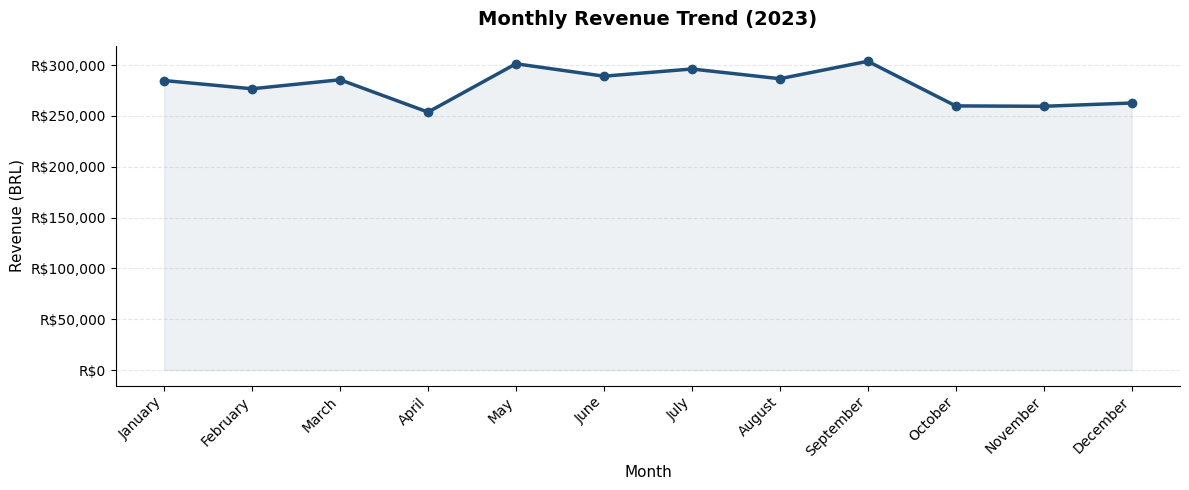

In [8]:
# Monthly revenue trend line chart
# Displayed only when analysing a full year (ANALYSIS_MONTH = None)
if ANALYSIS_MONTH is None:
    monthly_rev  = calculate_monthly_revenue(sales_current)
    month_labels = [pd.Timestamp(2020, m, 1).strftime('%B') for m in monthly_rev.index]
    x_pos        = range(len(month_labels))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(x_pos, monthly_rev.values, marker='o', color='#1F4E79',
            linewidth=2.5, markersize=6)
    ax.fill_between(x_pos, monthly_rev.values, alpha=0.08, color='#1F4E79')
    ax.set_title(f'Monthly Revenue Trend ({period_label})',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Month', fontsize=11)
    ax.set_ylabel('Revenue (BRL)', fontsize=11)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(month_labels, rotation=45, ha='right')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'R${x:,.0f}'))
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print(f'Monthly trend chart requires full-year analysis (ANALYSIS_MONTH = None).')

### 3.2 Product Analysis

Revenue breakdown by product category for the analysis period, ranked from
highest to lowest revenue.

In [9]:
category_revenue = calculate_revenue_by_category(sales_current, products)

print(f'Top 15 Product Categories by Revenue ({period_label})')
print('-' * 60)
for rank, (cat, rev) in enumerate(category_revenue.head(15).items(), start=1):
    print(f'  {rank:>2}. {cat:<40}  R${rev:>10,.2f}')
print(f'\nTotal categories with sales: {len(category_revenue)}')

Top 15 Product Categories by Revenue (2023)
------------------------------------------------------------
   1. electronics                               R$1,401,359.21
   2. home_garden                               R$862,653.27
   3. sports_outdoors                           R$278,845.32
   4. automotive                                R$247,707.10
   5. clothing_shoes_jewelry                    R$232,745.04
   6. toys_games                                R$ 70,163.64
   7. health_personal_care                      R$ 65,370.27
   8. tools_home_improvement                    R$ 54,280.33
   9. beauty_personal_care                      R$ 49,213.30
  10. books_media                               R$ 38,559.08
  11. grocery_gourmet_food                      R$ 26,964.36
  12. baby_products                             R$ 25,302.54
  13. pet_supplies                              R$  7,131.28

Total categories with sales: 13


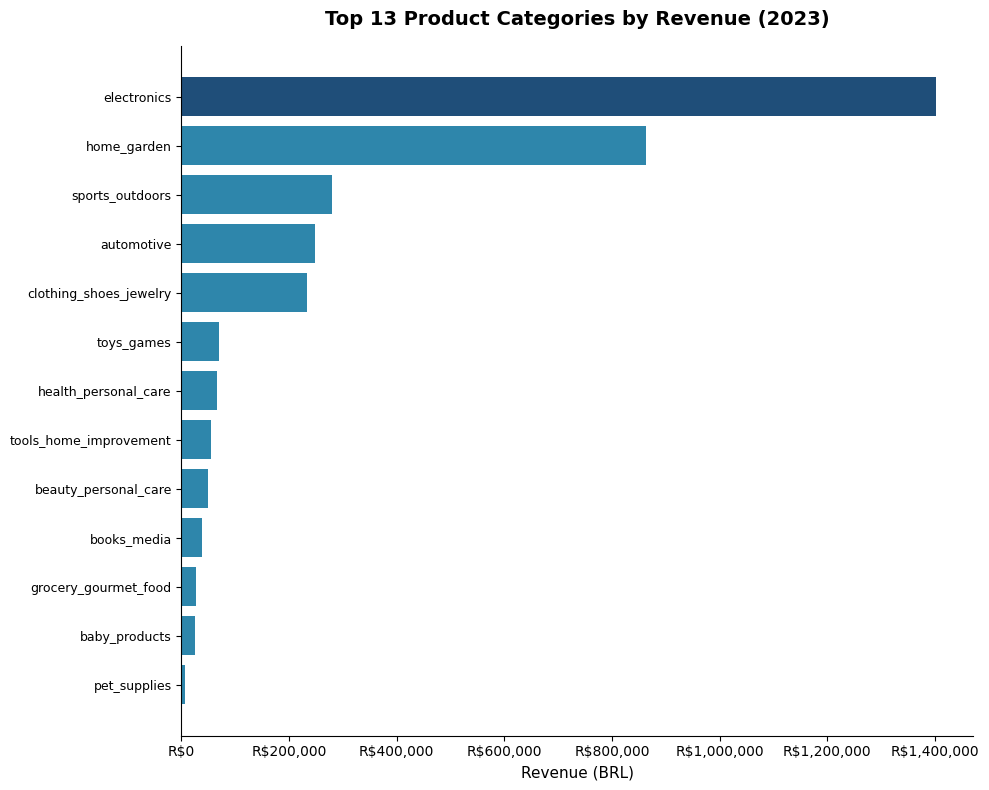

In [10]:
# Horizontal bar chart of the top 15 product categories
top_n          = 15
top_categories = category_revenue.head(top_n)
actual_n       = len(top_categories)

# Reverse order so the highest-revenue category appears at the top
cat_names = top_categories.index[::-1].tolist()
cat_vals  = top_categories.values[::-1]
bar_colors = ['#1F4E79'] + ['#2E86AB'] * (actual_n - 1)
bar_colors.reverse()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(actual_n), cat_vals, color=bar_colors)
ax.set_yticks(range(actual_n))
ax.set_yticklabels(cat_names, fontsize=9)
ax.set_title(
    f'Top {actual_n} Product Categories by Revenue ({period_label})',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Revenue (BRL)', fontsize=11)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'R${x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 3.3 Geographic Analysis

Revenue distribution across customer states for the analysis period.

In [11]:
state_revenue = calculate_revenue_by_state(sales_current, orders, customers)

print(f'Revenue by State - Top 10 ({period_label})')
print('-' * 40)
for _, row in state_revenue.head(10).iterrows():
    print(f'  {row["customer_state"]}:  R${row["price"]:>12,.2f}')

Revenue by State - Top 10 (2023)
----------------------------------------
  CA:  R$  537,880.74
  TX:  R$  403,303.49
  FL:  R$  310,195.84
  NY:  R$  253,111.85
  IL:  R$  185,930.89
  PA:  R$  173,260.68
  OH:  R$  157,619.72
  GA:  R$  146,414.65
  MI:  R$  132,325.60
  NC:  R$  128,314.74


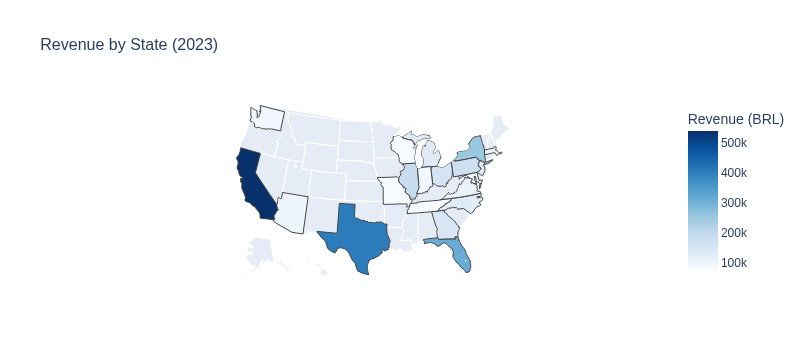

In [12]:
# Interactive choropleth map of revenue by state
fig = px.choropleth(
    state_revenue,
    locations='customer_state',
    color='price',
    locationmode='USA-states',
    scope='usa',
    title=f'Revenue by State ({period_label})',
    color_continuous_scale='Blues',
    labels={'price': 'Revenue (BRL)', 'customer_state': 'State'}
)
fig.update_layout(
    title_font_size=16,
    coloraxis_colorbar_title='Revenue (BRL)'
)
fig.show()

### 3.4 Customer Experience Analysis

Delivery speed distribution and its relationship to customer review scores for
the analysis period. Delivery speed is calculated as the number of days between
the purchase date and the customer delivery date.

In [13]:
# Add delivery speed columns to the current-period sales data
sales_with_delivery = calculate_delivery_metrics(sales_current)

In [14]:
# Calculate review metrics (requires delivery columns computed above)
review_metrics = calculate_review_metrics(sales_with_delivery, reviews)

print(f'Customer Experience Metrics ({period_label})')
print('=' * 50)
print()
print('Delivery Speed')
print('-' * 50)
print(f'  Average delivery time : {review_metrics["avg_delivery_speed"]:.1f} days')
print()
print('Review Scores')
print('-' * 50)
print(f'  Overall average score : {review_metrics["avg_score"]:.2f} / 5.0')
print()
print('Average Score by Delivery Speed Bucket')
print('-' * 50)
for _, row in review_metrics['score_by_delivery_bucket'].iterrows():
    print(f'  {row["delivery_time"]:<12}: {row["review_score"]:.2f} / 5.0')

Customer Experience Metrics (2023)

Delivery Speed
--------------------------------------------------
  Average delivery time : 8.0 days

Review Scores
--------------------------------------------------
  Overall average score : 4.10 / 5.0

Average Score by Delivery Speed Bucket
--------------------------------------------------
  1-3 days    : 4.19 / 5.0
  4-7 days    : 4.08 / 5.0
  8+ days     : 4.11 / 5.0


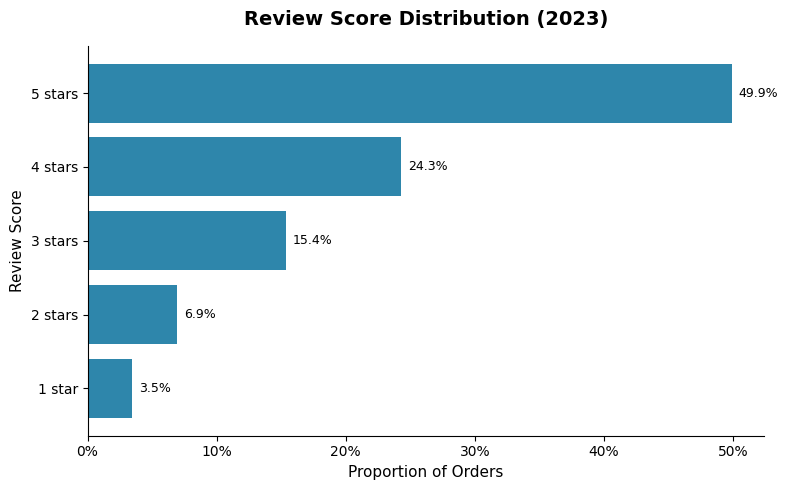

In [15]:
# Horizontal bar chart of review score distribution
score_dist   = review_metrics['score_distribution'].sort_index()
score_labels = [f'{int(s)} star{"s" if s > 1 else ""}' for s in score_dist.index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(score_labels, score_dist.values, color='#2E86AB')
ax.set_title(
    f'Review Score Distribution ({period_label})',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Proportion of Orders', fontsize=11)
ax.set_ylabel('Review Score', fontsize=11)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x:.0%}'))
for i, v in enumerate(score_dist.values):
    ax.text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [16]:
# Order status distribution for the analysis year (all statuses, not just delivered)
orders_with_year = orders.copy()
orders_with_year['year'] = pd.to_datetime(
    orders_with_year['order_purchase_timestamp']
).dt.year

order_status_dist = (
    orders_with_year[orders_with_year['year'] == ANALYSIS_YEAR]
    ['order_status']
    .value_counts(normalize=True)
)

print(f'Order Status Distribution ({ANALYSIS_YEAR})')
print('-' * 40)
for status, proportion in order_status_dist.items():
    print(f'  {status:<25}: {proportion:.1%}')

Order Status Distribution (2023)
----------------------------------------
  delivered                : 93.6%
  shipped                  : 3.2%
  canceled                 : 1.3%
  processing               : 1.2%
  pending                  : 0.5%
  returned                 : 0.2%


---
## 4. Summary of Observations

The cell below consolidates the key metrics computed throughout the notebook
into a single printable summary.

In [17]:
top_category    = category_revenue.index[0]
top_state       = state_revenue.iloc[0]['customer_state']
avg_score       = review_metrics['avg_score']
avg_delivery    = review_metrics['avg_delivery_speed']

print('=' * 60)
print(f'  E-Commerce Analysis Summary  |  {period_label}')
print('=' * 60)
print()
print('Revenue')
print(f'  Total revenue              : R${total_revenue:,.2f}')
print(f'  YoY revenue growth         : {revenue_growth:.1%}')
print(f'  Average order value (AOV)  : R${aov:,.2f}')
print(f'  YoY AOV growth             : {aov_growth:.1%}')
print()
print('Orders')
print(f'  Total orders               : {total_orders:,}')
print(f'  YoY order count growth     : {order_growth:.1%}')
print()
print('Products & Geography')
print(f'  Top product category       : {top_category}')
print(f'  Top revenue state          : {top_state}')
print()
print('Customer Experience')
print(f'  Average delivery time      : {avg_delivery:.1f} days')
print(f'  Average review score       : {avg_score:.2f} / 5.0')
print()
print('=' * 60)

  E-Commerce Analysis Summary  |  2023

Revenue
  Total revenue              : R$3,360,294.74
  YoY revenue growth         : -2.5%
  Average order value (AOV)  : R$724.98
  YoY AOV growth             : -0.1%

Orders
  Total orders               : 4,635
  YoY order count growth     : -2.4%

Products & Geography
  Top product category       : electronics
  Top revenue state          : CA

Customer Experience
  Average delivery time      : 8.0 days
  Average review score       : 4.10 / 5.0

